In [1]:
# TASK A
print("GANIKA R - 24BAD025")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully.")

GANIKA R - 24BAD025
TensorFlow Version: 2.21.0
Libraries imported successfully.


In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))
print("Training labels:", np.unique(y_train))
print("Testing labels:", np.unique(y_test))

print("\nFirst review (integer sequence):")
print(X_train_raw[0][:30])

print("\nFirst review sentiment:")
print("Positive" if y_train[0] == 1 else "Negative")

print("\nTraining class distribution:")
print(pd.Series(y_train).map({0: "Negative", 1: "Positive"}).value_counts())

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 25000
Testing samples: 25000
Training labels: [0 1]
Testing labels: [0 1]

First review (integer sequence):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]

First review sentiment:
Positive

Training class distribution:
Positive    12500
Negative    12500
Name: count, dtype: int64


In [3]:
word_index = imdb.get_word_index()
index_word = {index + 3: word for word, index in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(index_word.get(i, "?") for i in sequence)
for i in range(3):
    print(f"\nReview {i + 1}")
    print("Text:", decode_review(X_train_raw[i])[:700])
    print("Sentiment:", "Positive" if y_train[i] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Review 1
Text: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was als
Sentiment: Positive

Review 2
Text: <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of t

In [4]:
X_train = pad_sequences(
    X_train_raw, maxlen=MAX_LEN, padding="post", truncating="post"
)

X_test = pad_sequences(
    X_test_raw, maxlen=MAX_LEN, padding="post", truncating="post"
)

print("Padded training shape:", X_train.shape)
print("Padded testing shape:", X_test.shape)
print("\nFirst padded review:")
print(X_train[0])

print("\nSequence length:", len(X_train[0]))
print("Padding completed successfully.")

Padded training shape: (25000, 200)
Padded testing shape: (25000, 200)

First padded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22

In [5]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training data:", X_train_final.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

print("\nDataset preparation completed.")

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)

Dataset preparation completed.


In [6]:
# TASK B

EMBEDDING_DIM = 64

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

print("LSTM model created successfully.")

LSTM model created successfully.


In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [8]:
model.build(input_shape=(None, MAX_LEN))
model.summary()

print("\nTotal trainable and non-trainable parameters:")
print(model.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable and non-trainable parameters:
673089


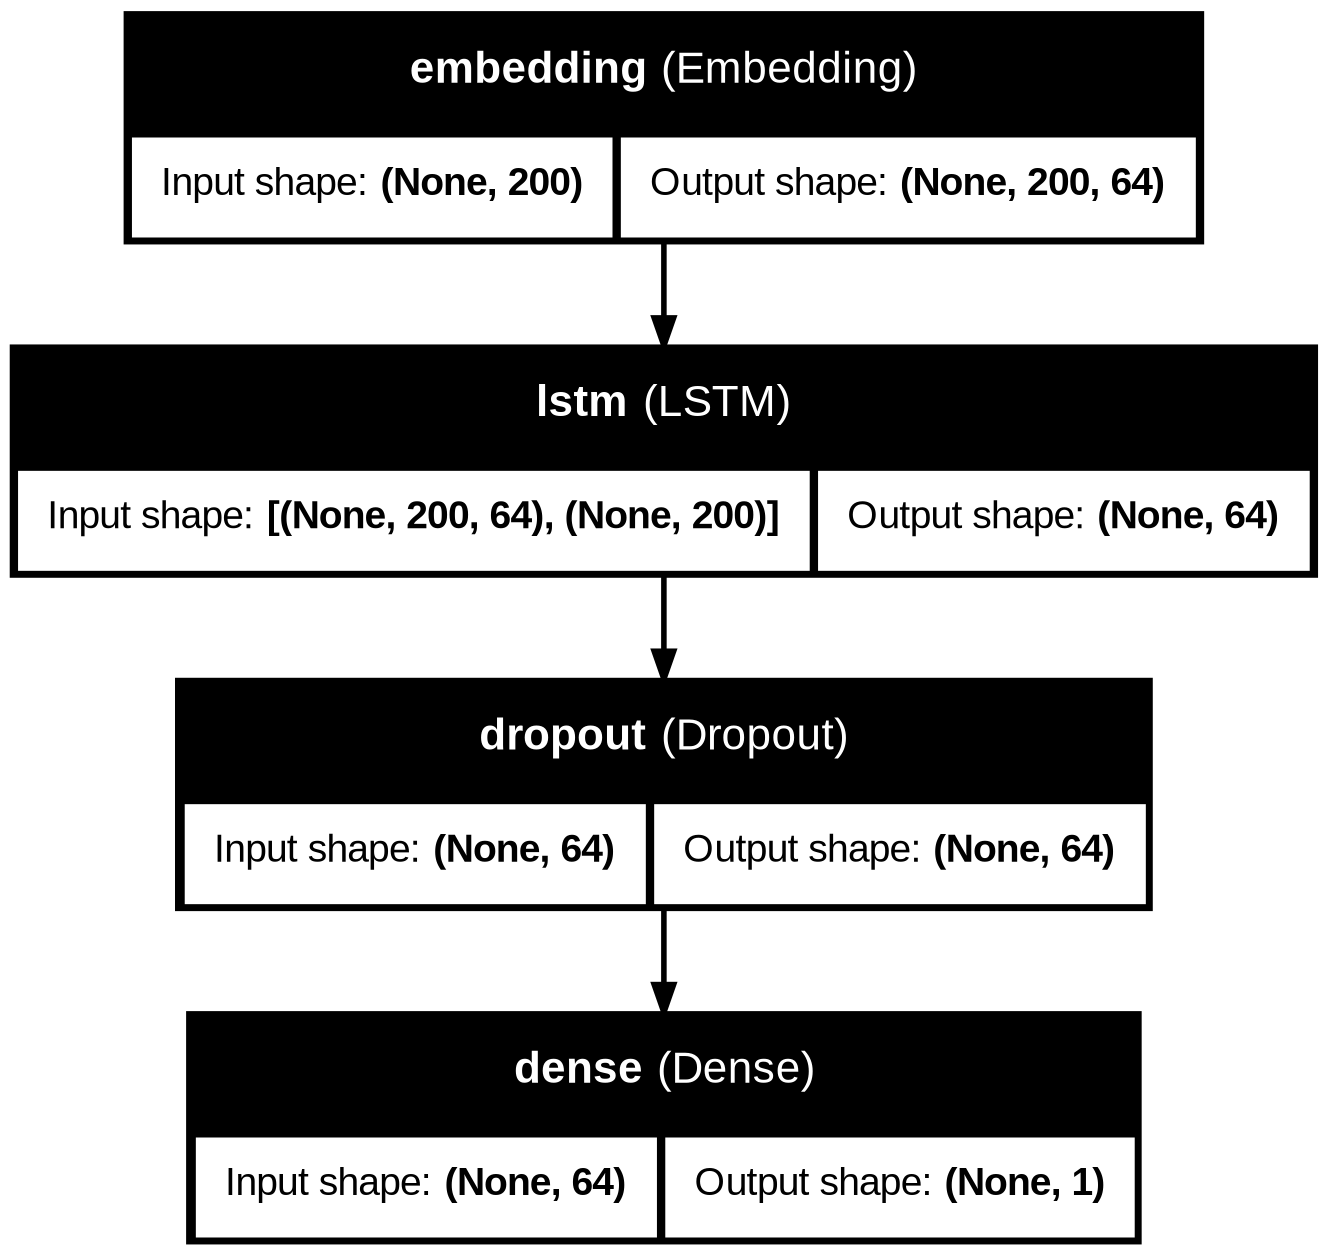

In [9]:
tf.keras.utils.plot_model(
    model,
    to_file="lstm_model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

from IPython.display import display, Image

display(Image(filename="lstm_model_architecture.png"))

In [10]:
# TASK C

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.7434 - loss: 0.5108 - val_accuracy: 0.8336 - val_loss: 0.3823
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 101s 647ms/step - accuracy: 0.8875 - loss: 0.2945 - val_accuracy: 0.7984 - val_loss: 0.4646
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 98s 622ms/step - accuracy: 0.9031 - loss: 0.2626 - val_accuracy: 0.8436 - val_loss: 0.3718
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 410ms/step - accuracy: 0.9156 - loss: 0.2283 - val_accuracy: 0.8284 - val_loss: 0.4340
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 435ms/step - accuracy: 0.9284 - loss: 0.1941 - val_accuracy: 0.7540 - val_loss: 0.6221


In [11]:
results = pd.DataFrame({
    "Epoch": range(1, len(history.history["loss"]) + 1),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

print(results.to_string(index=False))

print("\nFinal recorded training accuracy:",
      round(history.history["accuracy"][-1], 4))
print("Final recorded validation accuracy:",
      round(history.history["val_accuracy"][-1], 4))

 Epoch  Training Accuracy  Validation Accuracy  Training Loss  Validation Loss
     1            0.74345               0.8336       0.510850         0.382347
     2            0.88755               0.7984       0.294460         0.464576
     3            0.90310               0.8436       0.262558         0.371755
     4            0.91560               0.8284       0.228339         0.433995
     5            0.92845               0.7540       0.194119         0.622115

Final recorded training accuracy: 0.9284
Final recorded validation accuracy: 0.754


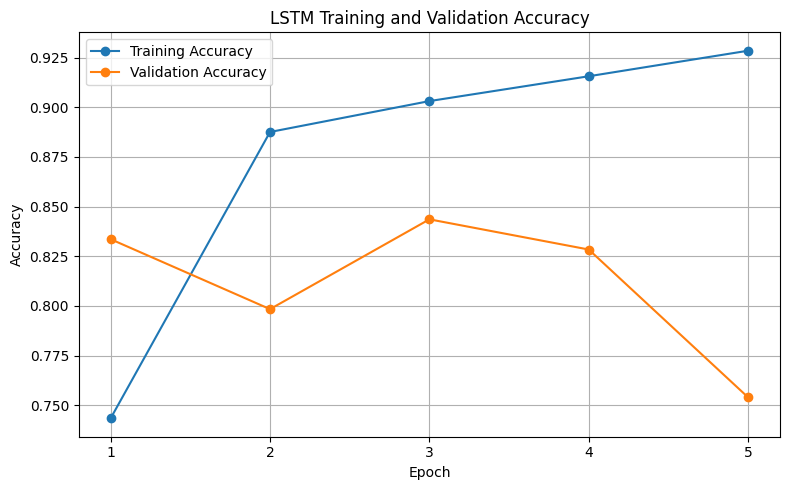

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(len(history.history["accuracy"])),
           range(1, len(history.history["accuracy"]) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

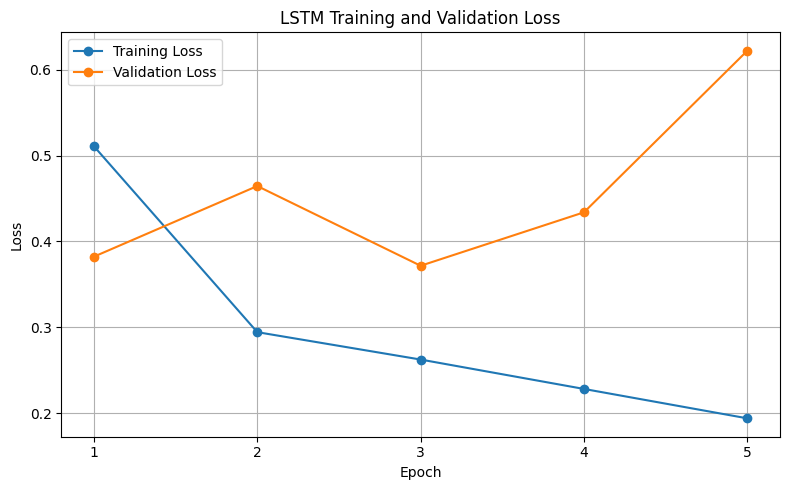

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(len(history.history["loss"])),
           range(1, len(history.history["loss"]) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test, y_test, verbose=1
)

y_prob = model.predict(X_test, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8368 - loss: 0.3866
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step

Test Loss: 0.3866
Test Accuracy: 0.8368


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Classification Metrics")
print("----------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nDetailed Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    zero_division=0
))

Classification Metrics
----------------------
Accuracy : 0.8368
Precision: 0.8539
Recall   : 0.8126
F1-score : 0.8328

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84     12500
    Positive       0.85      0.81      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



Confusion Matrix:
[[10762  1738]
 [ 2342 10158]]


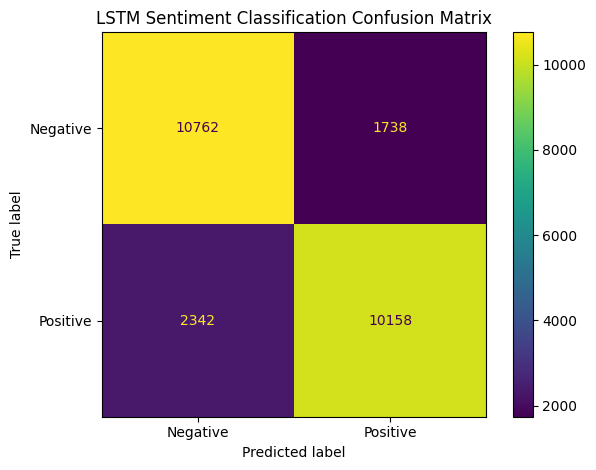

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(values_format="d")
plt.title("LSTM Sentiment Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
# TASK D

import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_review(text):
    words = re.findall(r"[a-z']+", text.lower())
    sequence = [1]

    for word in words:
        original_index = word_index.get(word)

        if original_index is None:
            index = 2
        else:
            index = original_index + 3
            if index >= VOCAB_SIZE:
                index = 2

        sequence.append(index)

    padded_sequence = pad_sequences(
        [sequence],
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    return padded_sequence

sample_review = "This movie was wonderful and the acting was excellent."
processed_review = preprocess_review(sample_review)

print("Original Review:", sample_review)
print("Preprocessed Sequence:")
print(processed_review)
print("Sequence Shape:", processed_review.shape)

Original Review: This movie was wonderful and the acting was excellent.
Preprocessed Sequence:
[[  1  14  20  16 389   5   4 116  16 321   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]]
Sequence Shape: (1, 200)


In [18]:
reviews = [
    {
        "text": "This movie was absolutely wonderful and the acting was excellent.",
        "expected": "Positive"
    },
    {
        "text": "The film was boring, poorly written, and a complete disappointment.",
        "expected": "Negative"
    },
    {
        "text": "I loved the story and the characters were very entertaining.",
        "expected": "Positive"
    },
    {
        "text": "The movie was terrible and I regret watching it.",
        "expected": "Negative"
    },
    {
        "text": "The movie had some good moments but the ending was disappointing.",
        "expected": "Negative"
    },
    {
        "text": "An enjoyable film with brilliant performances and a great story.",
        "expected": "Positive"
    }
]

for item in reviews:
    processed = preprocess_review(item["text"])
    probability = float(model.predict(processed, verbose=0)[0][0])

    predicted = "Positive" if probability >= 0.5 else "Negative"

    print("Review:", item["text"])
    print("Expected Sentiment:", item["expected"])
    print("Predicted Sentiment:", predicted)
    print("Positive Probability:", round(probability, 4))
    print("Correct:", predicted == item["expected"])
    print("-" * 70)

Review: This movie was absolutely wonderful and the acting was excellent.
Expected Sentiment: Positive
Predicted Sentiment: Positive
Positive Probability: 0.9687
Correct: True
----------------------------------------------------------------------
Review: The film was boring, poorly written, and a complete disappointment.
Expected Sentiment: Negative
Predicted Sentiment: Negative
Positive Probability: 0.0159
Correct: True
----------------------------------------------------------------------
Review: I loved the story and the characters were very entertaining.
Expected Sentiment: Positive
Predicted Sentiment: Positive
Positive Probability: 0.9293
Correct: True
----------------------------------------------------------------------
Review: The movie was terrible and I regret watching it.
Expected Sentiment: Negative
Predicted Sentiment: Negative
Positive Probability: 0.2403
Correct: True
----------------------------------------------------------------------
Review: The movie had some good 

In [19]:
prediction_results = []

for item in reviews:
    processed = preprocess_review(item["text"])
    probability = float(model.predict(processed, verbose=0)[0][0])
    predicted = "Positive" if probability >= 0.5 else "Negative"

    prediction_results.append({
        "Review": item["text"],
        "Expected": item["expected"],
        "Predicted": predicted,
        "Positive Probability": round(probability, 4),
        "Correct": predicted == item["expected"]
    })

prediction_df = pd.DataFrame(prediction_results)
display(prediction_df)

correct_predictions = sum(
    row["Correct"] for row in prediction_results
)

print("Correct predictions:", correct_predictions, "out of", len(reviews))
print("Sample prediction accuracy:",
      round(correct_predictions / len(reviews) * 100, 2), "%")

,Review,Expected,Predicted,Positive Probability,Correct
0,This movie was absolutely wonderful and the ac...,Positive,Positive,0.9687,True
1,"The film was boring, poorly written, and a com...",Negative,Negative,0.0159,True
2,I loved the story and the characters were very...,Positive,Positive,0.9293,True
3,The movie was terrible and I regret watching it.,Negative,Negative,0.2403,True
4,The movie had some good moments but the ending...,Negative,Negative,0.2769,True
5,An enjoyable film with brilliant performances ...,Positive,Positive,0.9807,True


Correct predictions: 6 out of 6
Sample prediction accuracy: 100.0 %


In [20]:
import json

model.save("lstm_sentiment_model.keras")

with open("imdb_word_index.json", "w") as file:
    json.dump(word_index, file)

print("Model saved as lstm_sentiment_model.keras")
print("Vocabulary saved as imdb_word_index.json")

Model saved as lstm_sentiment_model.keras
Vocabulary saved as imdb_word_index.json


In [21]:
from google.colab import files

files.download("lstm_sentiment_model.keras")
files.download("imdb_word_index.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>